In [74]:
# %% -----------------------------------------------
# MULTI-FIDELITY DOUBLE PENDULUM: 10 HF & 100 LF
# ----------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import pysindy as ps
from pysindy.feature_library import WeakPDELibrary

plt.style.use("dark_background")
rng = np.random.default_rng(42)


In [75]:
# -----------------------------------------------------
# Double pendulum dynamics
# state u = [theta1, omega1, theta2, omega2]
# -----------------------------------------------------
def double_pendulum(t, u, m1=1.0, m2=1.0, L1=1.0, L2=1.0, g=9.81):
    th1, w1, th2, w2 = u
    delta = th2 - th1

    den1 = (m1 + m2) * L1 - m2 * L1 * np.cos(delta) ** 2
    den2 = (L2 / L1) * den1

    dth1 = w1
    dth2 = w2

    dw1 = (
        m2 * L1 * w1 ** 2 * np.sin(delta) * np.cos(delta)
        + m2 * g * np.sin(th2) * np.cos(delta)
        + m2 * L2 * w2 ** 2 * np.sin(delta)
        - (m1 + m2) * g * np.sin(th1)
    ) / den1

    dw2 = (
        -m2 * L2 * w2 ** 2 * np.sin(delta) * np.cos(delta)
        + (m1 + m2)
        * (
            g * np.sin(th1) * np.cos(delta)
            - L1 * w1 ** 2 * np.sin(delta)
            - g * np.sin(th2)
        )
    ) / den2

    return np.array([dth1, dw1, dth2, dw2])


def simulate_double_pendulum(u0, T, dt):
    t = np.arange(0.0, T, dt)
    sol = solve_ivp(
        double_pendulum,
        (t[0], t[-1]),
        u0,
        t_eval=t,
        atol=1e-10,
        rtol=1e-10,
    )
    return t, sol.y.T  # (Nt, 4)


In [76]:
# -----------------------------------------------------
# Parameters
# -----------------------------------------------------
dt = 1e-3
T_train = 5.0
T_test = 5.0

# HF / LF noise (relative to state std)
noise_hf_rel = 0.01
noise_lf_rel = 0.10

n_hf = 2
n_lf = 20


In [77]:
# -----------------------------------------------------
# Reference trajectory to set noise scale
# -----------------------------------------------------
u0_ref = rng.uniform(
    low=np.array([-0.5, -0.5, -0.5, -0.5]),
    high=np.array([0.5,  0.5,  0.5,  0.5]),
)
t_train, U_ref = simulate_double_pendulum(u0_ref, T_train, dt)
state_std = float(np.std(U_ref))

noise_hf = noise_hf_rel * state_std
noise_lf = noise_lf_rel * state_std

print("state_std:", state_std)
print("noise_hf:", noise_hf, "noise_lf:", noise_lf)


state_std: 0.4311515585593769
noise_hf: 0.004311515585593769 noise_lf: 0.0431151558559377


In [78]:
# -----------------------------------------------------
# Generate HF + LF training datasets
# -----------------------------------------------------
U_hf_list, U_lf_list = [], []
u0 = rng.uniform(-0.5, 0.5, size=4)

for _ in range(n_hf):
    _, U = simulate_double_pendulum(u0, T_train, dt)
    U_hf_list.append(U + noise_hf * rng.standard_normal(U.shape))

for _ in range(n_lf):
    _, U = simulate_double_pendulum(u0, T_train, dt)
    U_lf_list.append(U + noise_lf * rng.standard_normal(U.shape))

U_mf_list = U_hf_list + U_lf_list


In [82]:
# -----------------------------------------------------
# Weak SINDy ensemble (degree-3 polynomial library)
# -----------------------------------------------------
T_grid = t_train[:, None]

poly = ps.PolynomialLibrary(degree=3, include_bias=False)

weak_lib = WeakPDELibrary(
    function_library=poly,
    derivative_order=1,
    spatiotemporal_grid=T_grid,
    include_bias=False,
    K=1000,
    # H_xt = 0.005,
    is_uniform=True,
)

def make_ens():
    return ps.EnsembleOptimizer(
        ps.STLSQ(threshold=0.5, alpha=1e-12),
        bagging=True,
    )

opt_hf  = make_ens()
opt_lf  = make_ens()
opt_mf  = make_ens()
opt_mfw = make_ens()

model_hf   = ps.SINDy(feature_library=weak_lib, optimizer=opt_hf)
model_lf   = ps.SINDy(feature_library=weak_lib, optimizer=opt_lf)
model_mf   = ps.SINDy(feature_library=weak_lib, optimizer=opt_mf)
model_mfw  = ps.SINDy(feature_library=weak_lib, optimizer=opt_mfw)

# Fit HF / LF / MF / WMF
# model_hf.fit(U_hf_list, t=t_train)
# model_lf.fit(U_lf_list, t=t_train)
model_mf.fit(U_mf_list, t=t_train)

weights = [1 / noise_hf**2] * n_hf + [1 / noise_lf**2] * n_lf
model_mfw.fit(U_mf_list, t=t_train, sample_weight=weights)

# model_hf.print()
# model_lf.print()
model_mf.print()
model_mfw.print()


/Users/filippozacchei/Library/CloudStorage/OneDrive-PolitecnicodiMilano/Documenti/Projects/PySINDy/pysindy/feature_library/weak_pde_library.py:177: UserWarning: is_uniform and periodic have been deprecated.in favor of differetiation_method and diff_kwargs.
  warnings.warn(
/Users/filippozacchei/Library/CloudStorage/OneDrive-PolitecnicodiMilano/Documenti/Projects/PySINDy/pysindy/utils/_axes.py:127: AxesWarning: 2 axes labeled for array with 1 axes
  warnings.warn(
/Users/filippozacchei/Library/CloudStorage/OneDrive-PolitecnicodiMilano/Documenti/Projects/PySINDy/pysindy/utils/_axes.py:127: AxesWarning: 2 axes labeled for array with 1 axes
  warnings.warn(


(x0)' = 0.998 x1
(x1)' = -24.604 x0 + 1.260 x2 + 34.486 x0^3 + -11.075 x0^2 x2 + 0.939 x0 x1 x3 + 46.344 x0 x2^2 + 4.911 x1^2 x2 + 4.760 x1 x2 x3 + 10.555 x2^3 + 3.067 x2 x3^2
(x2)' = 1.000 x3
(x3)' = 24.967 x0 + -9.760 x2 + -42.668 x0^3 + 26.316 x0^2 x2 + -0.890 x0 x1 x3 + -30.359 x0 x2^2 + -3.788 x1^2 x2 + -0.934 x1 x2 x3 + -4.789 x2^3 + -1.760 x2 x3^2
(x0)' = 1.000 x1
(x1)' = -16.096 x0 + -5.997 x0^2 x2 + -2.555 x0 x1^2 + -1.939 x0 x1 x3 + -2.889 x0 x2^2 + -1.726 x0 x3^2 + 2.457 x1^2 x2 + 6.825 x2^3 + 1.613 x2 x3^2
(x2)' = 1.000 x3
(x3)' = 14.756 x0 + -6.891 x2 + -2.128 x0^3 + 12.737 x0^2 x2 + 4.014 x0 x1^2 + 2.449 x0 x1 x3 + 4.103 x0 x2^2 + 1.933 x0 x3^2 + -3.840 x1^2 x2 + -8.002 x2^3 + -1.757 x2 x3^2


In [83]:
# -----------------------------------------------------
# Copy coefficients into standard SINDy models for simulate
# -----------------------------------------------------

def build_forecast_model(coef, X_ref, t_ref):
    model = ps.SINDy(feature_library=poly, optimizer=ps.STLSQ(alpha=0.0))
    model.fit(X_ref, t=t_ref)  # initialise shapes

    C = np.array(coef, dtype=float)
    C[~np.isfinite(C)] = 0.0
    C = np.clip(C, -200, 200)

    model.optimizer.coef_ = C
    return model

import tqdm
def simulate_ensemble(model_weak, u0_test, t_test, X_ref, t_ref):
    preds = []
    for coef in tqdm.tqdm(model_weak.optimizer.coef_list[:10]):
        try:
            m = build_forecast_model(coef, X_ref, t_ref)
            preds.append(m.simulate(u0_test, t_test))
        except Exception:
            preds.append(np.nan * np.zeros((len(t_test), X_ref.shape[1])))
    P = np.array(preds)
    return np.nanmean(P, axis=0), np.nanstd(P, axis=0)



In [84]:
# -----------------------------------------------------
# Forecast comparison on a test trajectory
# -----------------------------------------------------
T_test = 10.0
t_test = np.arange(0.0, T_test, dt)
u0_test = rng.uniform(-0.5, 0.5, size=4)

_, U_true = simulate_double_pendulum(u0_test, T_test, dt)

X_ref = U_hf_list[0]
t_ref = t_train

# U_hf_mean,  U_hf_std  = simulate_ensemble(model_hf,  u0_test, t_test, X_ref, t_ref)
# U_lf_mean,  U_lf_std  = simulate_ensemble(model_lf,  u0_test, t_test, X_ref, t_ref)
U_mf_mean,  U_mf_std  = simulate_ensemble(model_mf,  u0_test, t_test, X_ref, t_ref)
U_wmf_mean, U_wmf_std = simulate_ensemble(model_mfw, u0_test, t_test, X_ref, t_ref)


 10%|█         | 1/10 [00:05<00:52,  5.79s/it]

 lsoda--  warning..internal t (=r1) and h (=r2) are  
       such that in the machine, t + h = t on the next step  
       (h = step size). solver will continue anyway  
      in above,  r1 =  0.2416376608460D+01   r2 =  0.2048721860948D-15
 lsoda--  warning..internal t (=r1) and h (=r2) are  
       such that in the machine, t + h = t on the next step  
       (h = step size). solver will continue anyway  
      in above,  r1 =  0.2416376608460D+01   r2 =  0.2048721860948D-15
 lsoda--  warning..internal t (=r1) and h (=r2) are  
       such that in the machine, t + h = t on the next step  
       (h = step size). solver will continue anyway  
      in above,  r1 =  0.2416376608460D+01   r2 =  0.2048721860948D-15
 lsoda--  warning..internal t (=r1) and h (=r2) are  
       such that in the machine, t + h = t on the next step  
       (h = step size). solver will continue anyway  
      in above,  r1 =  0.2416376608460D+01   r2 =  0.2048721860948D-15
 lsoda--  warning..internal t (=r1) 

/Users/filippozacchei/Library/CloudStorage/OneDrive-PolitecnicodiMilano/Documenti/Projects/PySINDy/pysindy/utils/_axes.py:390: RuntimeWarning: overflow encountered in reduce
  results = super().__array_ufunc__(ufunc, method, *args, **kwargs)
capi_return is NULL
Call-back cb_f_in_lsoda__user__routines failed.
 60%|██████    | 6/10 [01:16<00:35,  8.97s/it]

 lsoda--  warning..internal t (=r1) and h (=r2) are  
       such that in the machine, t + h = t on the next step  
       (h = step size). solver will continue anyway  
      in above,  r1 =  0.4782960250658D+01   r2 =  0.4023087123260D-15
 lsoda--  warning..internal t (=r1) and h (=r2) are  
       such that in the machine, t + h = t on the next step  
       (h = step size). solver will continue anyway  
      in above,  r1 =  0.4782960250658D+01   r2 =  0.4023087123260D-15
 lsoda--  warning..internal t (=r1) and h (=r2) are  
       such that in the machine, t + h = t on the next step  
       (h = step size). solver will continue anyway  
      in above,  r1 =  0.4782960250658D+01   r2 =  0.4023087123260D-15
 lsoda--  warning..internal t (=r1) and h (=r2) are  
       such that in the machine, t + h = t on the next step  
       (h = step size). solver will continue anyway  
      in above,  r1 =  0.4782960250658D+01   r2 =  0.4023087123260D-15
 lsoda--  warning..internal t (=r1) 

/Users/filippozacchei/Library/CloudStorage/OneDrive-PolitecnicodiMilano/Documenti/Projects/PySINDy/pysindy/utils/_axes.py:390: RuntimeWarning: overflow encountered in reduce
  results = super().__array_ufunc__(ufunc, method, *args, **kwargs)
 70%|███████   | 7/10 [02:07<01:07, 22.62s/it]capi_return is NULL
Call-back cb_f_in_lsoda__user__routines failed.


 lsoda--  warning..internal t (=r1) and h (=r2) are  
       such that in the machine, t + h = t on the next step  
       (h = step size). solver will continue anyway  
      in above,  r1 =  0.7520817896123D+01   r2 =  0.1575420714394D-15
 lsoda--  warning..internal t (=r1) and h (=r2) are  
       such that in the machine, t + h = t on the next step  
       (h = step size). solver will continue anyway  
      in above,  r1 =  0.7520817896123D+01   r2 =  0.1575420714394D-15
 lsoda--  warning..internal t (=r1) and h (=r2) are  
       such that in the machine, t + h = t on the next step  
       (h = step size). solver will continue anyway  
      in above,  r1 =  0.7520817896123D+01   r2 =  0.1575420714394D-15
 lsoda--  warning..internal t (=r1) and h (=r2) are  
       such that in the machine, t + h = t on the next step  
       (h = step size). solver will continue anyway  
      in above,  r1 =  0.7520817896123D+01   r2 =  0.1575420714394D-15
 lsoda--  warning..internal t (=r1) 

/Users/filippozacchei/Library/CloudStorage/OneDrive-PolitecnicodiMilano/Documenti/Projects/PySINDy/pysindy/utils/_axes.py:390: RuntimeWarning: overflow encountered in reduce
  results = super().__array_ufunc__(ufunc, method, *args, **kwargs)
capi_return is NULL
Call-back cb_f_in_lsoda__user__routines failed.
 80%|████████  | 8/10 [04:40<02:08, 64.17s/it]

 lsoda--  warning..internal t (=r1) and h (=r2) are  
       such that in the machine, t + h = t on the next step  
       (h = step size). solver will continue anyway  
      in above,  r1 =  0.5093521574700D+01   r2 =  0.3987738430330D-15
 lsoda--  warning..internal t (=r1) and h (=r2) are  
       such that in the machine, t + h = t on the next step  
       (h = step size). solver will continue anyway  
      in above,  r1 =  0.5093521574700D+01   r2 =  0.3987738430330D-15
 lsoda--  warning..internal t (=r1) and h (=r2) are  
       such that in the machine, t + h = t on the next step  
       (h = step size). solver will continue anyway  
      in above,  r1 =  0.5093521574700D+01   r2 =  0.3987738430330D-15
 lsoda--  warning..internal t (=r1) and h (=r2) are  
       such that in the machine, t + h = t on the next step  
       (h = step size). solver will continue anyway  
      in above,  r1 =  0.5093521574700D+01   r2 =  0.3987738430330D-15
 lsoda--  warning..internal t (=r1) 

/Users/filippozacchei/Library/CloudStorage/OneDrive-PolitecnicodiMilano/Documenti/Projects/PySINDy/pysindy/utils/_axes.py:390: RuntimeWarning: overflow encountered in reduce
  results = super().__array_ufunc__(ufunc, method, *args, **kwargs)
capi_return is NULL
Call-back cb_f_in_lsoda__user__routines failed.
100%|██████████| 10/10 [00:52<00:00,  5.20s/it]


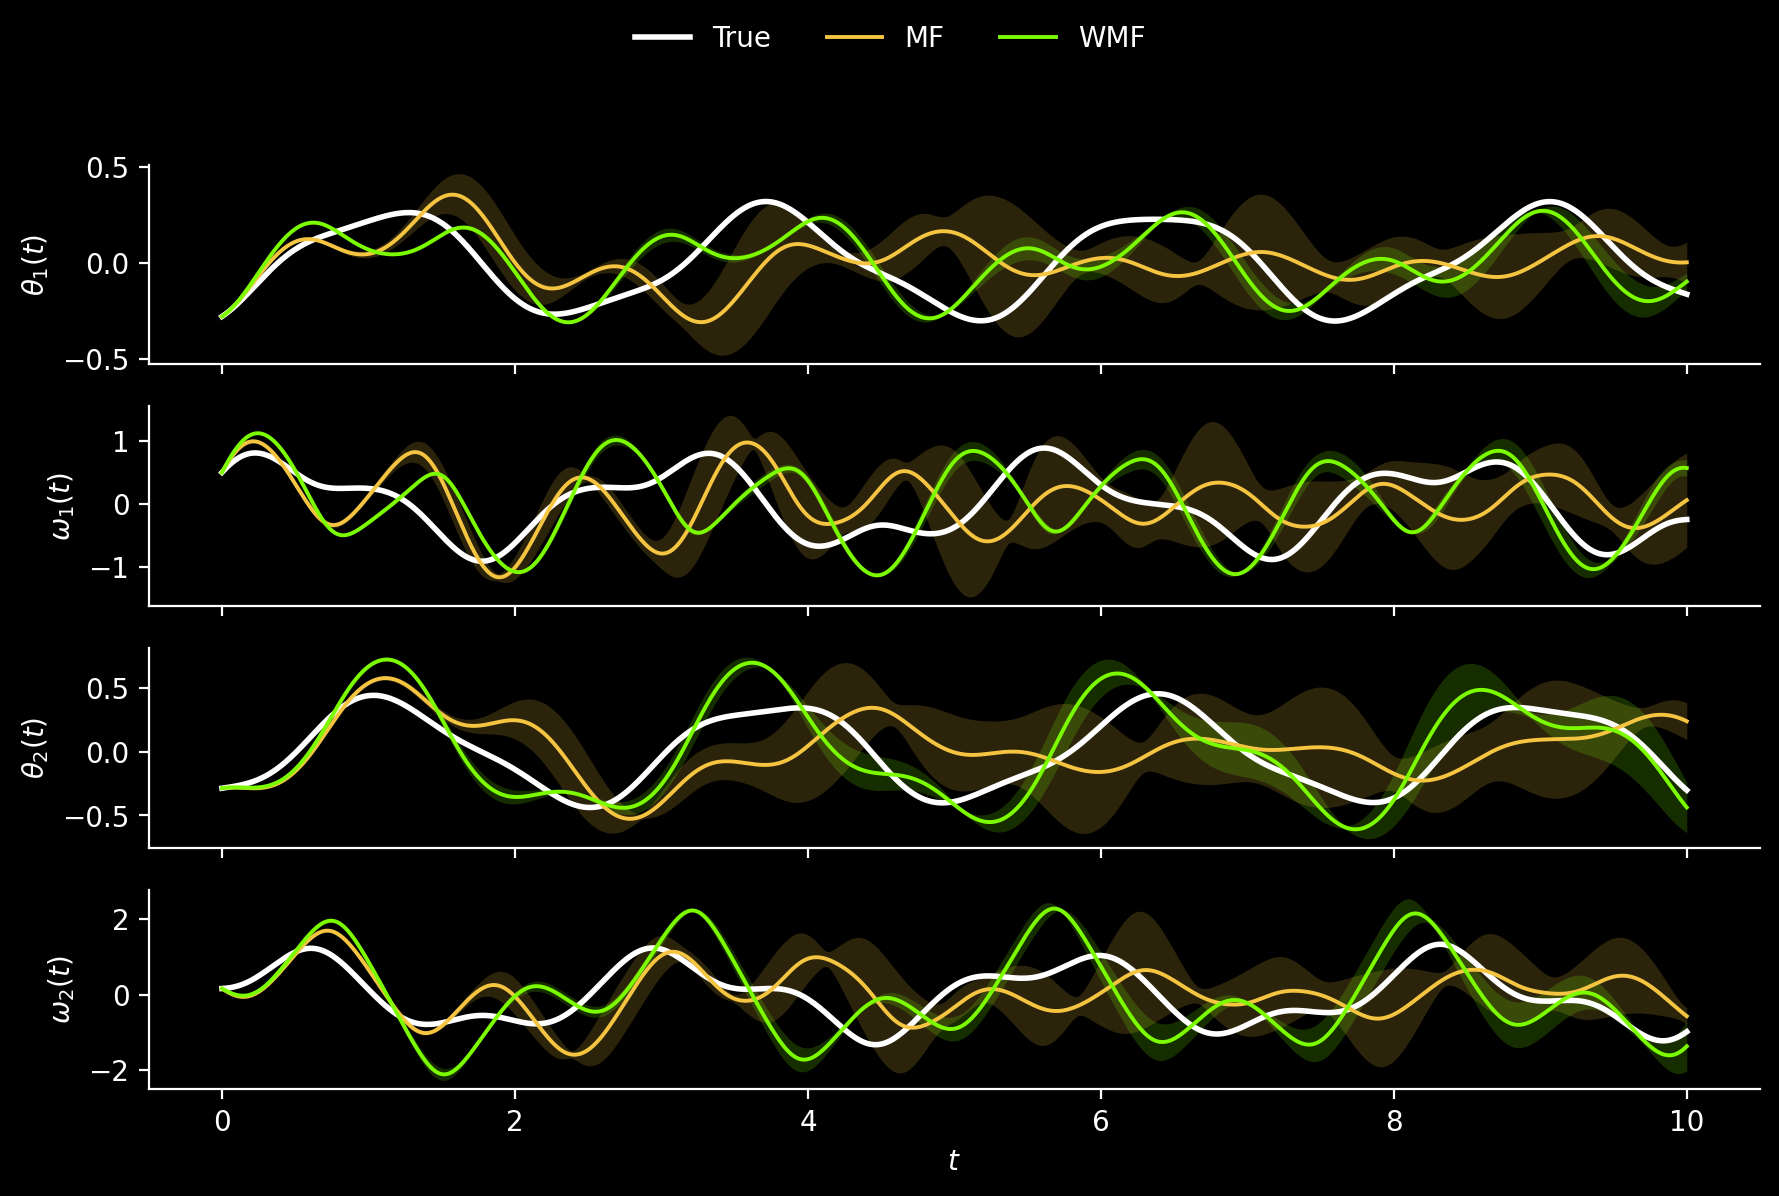

In [85]:
# -----------------------------------------------------
# Plot: four coordinates with uncertainty
# -----------------------------------------------------
fig, axes = plt.subplots(4, 1, figsize=(9, 6), sharex=True, dpi=200)

coord_labels = [r"$\theta_1(t)$", r"$\omega_1(t)$",
                r"$\theta_2(t)$", r"$\omega_2(t)$"]

col_true = "white"
col_hf   = "#4296f5"
col_lf   = "#f56942"
col_mf   = "#f5c542"
col_mfw  = "#7CFC00"

for i, ax in enumerate(axes):
    # true
    ax.plot(t_test, U_true[:, i], color=col_true, lw=2.0,
            label="True" if i == 0 else None)

    # HF
#     ax.fill_between(t_test,
#                     U_hf_mean[:, i] - U_hf_std[:, i],
#                     U_hf_mean[:, i] + U_hf_std[:, i],
#                     color=col_hf, alpha=0.18, linewidth=0.0)
#     ax.plot(t_test, U_hf_mean[:, i], color=col_hf, lw=1.4,
#             label="HF" if i == 0 else None)

#     # LF
#     ax.fill_between(t_test,
#                     U_lf_mean[:, i] - U_lf_std[:, i],
#                     U_lf_mean[:, i] + U_lf_std[:, i],
#                     color=col_lf, alpha=0.18, linewidth=0.0)
#     ax.plot(t_test, U_lf_mean[:, i], color=col_lf, lw=1.4,
#             label="LF" if i == 0 else None)

    # MF (unweighted)
    ax.fill_between(t_test,
                    U_mf_mean[:, i] - U_mf_std[:, i],
                    U_mf_mean[:, i] + U_mf_std[:, i],
                    color=col_mf, alpha=0.18, linewidth=0.0)
    ax.plot(t_test, U_mf_mean[:, i], color=col_mf, lw=1.4,
            label="MF" if i == 0 else None)

    # WMF (weighted)
    ax.fill_between(t_test,
                    U_wmf_mean[:, i] - U_wmf_std[:, i],
                    U_wmf_mean[:, i] + U_wmf_std[:, i],
                    color=col_mfw, alpha=0.18, linewidth=0.0)
    ax.plot(t_test, U_wmf_mean[:, i], color=col_mfw, lw=1.4,
            label="WMF" if i == 0 else None)

    ax.set_ylabel(coord_labels[i])
    ax.grid(False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[-1].set_xlabel(r"$t$")
fig.legend(loc="upper center", ncol=5, frameon=False)
plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()
